# 🎓 Семинар: Обучение линейной модели на классификацию аудио

На этом занятии мы разберем полный цикл обучения классификатора речевых цифр:
1. Загрузим датасет **AudioMNIST**
2. Напишем кастомный `Dataset`
3. Реализуем **линейные слои с ручным `forward` и `backward`**
4. Добавим активацию **ReLU** и второй слой
5. Напишем **SGD-оптимизатор**
6. Запустим полный цикл обучения

In [1]:
import os
import glob
import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

torch.manual_seed(42)
np.random.seed(42)

## Загрузка AudioMNIST

Датасет содержит ~30 000 аудиофайлов с записями произнесения цифр от 0 до 9.

Каждый файл имеет частоту дискретизации 16 кГц и длительность ~1 сек. Мы будем приводить все сэмплы к фиксированной длине `16000` точек.

In [2]:
%pip install gdown -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import gdown
import zipfile

FILE_ID = "13E8JVJdNYS9K9ubdGcruLSMLUD10OLbx"
output = "audio_mnist.zip"

if not os.path.exists(output):
    gdown.download(id=FILE_ID, output=output, quiet=False)

# Распаковка
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(".")

## Реализация `torch.utils.data.Dataset`

Класс должен реализовывать:
- `__len__`: возвращает количество семплов
- `__getitem__`: загружает аудио, приводит к фиксированной длине, нормализует, возвращает тензор и метку

In [4]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, target_len=16000):
        self.root_dir = root_dir
        self.target_len = target_len
        self.files = []
        self.labels = []

        # Сканируем все папки дикторов (00, 01, ..., 59)
        speaker_dirs = [d for d in glob.glob(os.path.join(root_dir, "*")) if os.path.isdir(d)]

        for speaker_dir in speaker_dirs:
            wav_paths = glob.glob(os.path.join(speaker_dir, "*.wav"))
            for wav_path in wav_paths:
                # Извлекаем метку из имени файла: "5_00_12.wav" -> "5"
                basename = os.path.basename(wav_path)
                label_str = basename.split("_")[0]

                # Безопасная проверка, что метка цифра от 0 до 9
                if label_str.isdigit() and (int(label_str) == 9 or int(label_str) == 0):
                    self.files.append(wav_path)
                    self.labels.append(0 if int(label_str) == 0 else 1)

        # Сортируем для воспроизводимости
        sorted_pairs = sorted(zip(self.labels, self.files))
        self.labels, self.files = [list(x) for x in zip(*sorted_pairs)]

        print(f"Найдено {len(self.files)} аудиофайлов")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        wav_path = self.files[idx]
        label = self.labels[idx]

        # Загрузка аудио
        waveform, sr = None

        # Mono
        if waveform.shape[0] > 1:
            waveform = None

        # Padding / Truncation до target_len
        if waveform.shape[1] < self.target_len:
            pad = self.target_len - waveform.shape[1]
            waveform = torch.nn.functional.pad(waveform, (0, pad))
        else:
            waveform = waveform[:, :self.target_len]

        # Нормализация в [-1, 1]
        waveform = waveform.squeeze()
        peak = None
        if peak > 0:
            waveform = waveform / peak

        return waveform.float(), torch.tensor(label, dtype=torch.long)

In [5]:
train_dataset = AudioMNISTDataset('data', target_len=16000)

Найдено 6000 аудиофайлов


In [6]:
train_dataset[0]

(tensor([ 0.0238,  0.0222,  0.0238,  ..., -0.6238, -0.6476, -0.6683]),
 tensor(0))

## Кастомный линейный слой

Формула прямого распространения (Forward):
$$ \mathbf{y} = \mathbf{x} \mathbf{W}^\top + \mathbf{b} $$
где:
- $\mathbf{x} \in \mathbb{R}^{B \times D_{in}}$ — вход (batch size $B$, входов $D_{in}$)
- $\mathbf{W} \in \mathbb{R}^{D_{out} \times D_{in}}$ — веса
- $\mathbf{b} \in \mathbb{R}^{D_{out}}$ — смещение
- $\mathbf{y} \in \mathbb{R}^{B \times D_{out}}$ — выход

Градиенты (Backward) вычисляются через цепное правило:
$$ \frac{\partial \mathcal{L}}{\partial \mathbf{W}} = \delta^\top \mathbf{x}, \quad \frac{\partial \mathcal{L}}{\partial \mathbf{b}} = \sum_{i=1}^B \delta_i, \quad \frac{\partial \mathcal{L}}{\partial \mathbf{x}} = \delta \mathbf{W} $$
где $\delta = \frac{\partial \mathcal{L}}{\partial \mathbf{y}}$ — градиент, пришедший с последующего слоя.

In [7]:
class ManualLinear:
    def __init__(self, in_features, out_features):
        # Инициализация весов (Kaiming uniform)
        scale = np.sqrt(2.0 / in_features)
        self.W = None
        self.b = None
        self.W.requires_grad = False  # Мы будем обновлять вручную
        self.b.requires_grad = False

    def forward(self, x):
        self.input = x  # Сохраняем для backward
        return None

    def backward(self, grad_output):
        # grad_output имеет shape (batch, out_features)
        # Градиенты по параметрам
        self.grad_W = None
        self.grad_b = None

        # Градиент по входу (для передачи назад)
        grad_input = None
        return grad_input

## ReLU и полный градиентный спуск

**ReLU Forward:**
$$ a = \max(0, z) $$
**ReLU Backward:**
$$ \frac{\partial \mathcal{L}}{\partial z} = \frac{\partial \mathcal{L}}{\partial a} \odot \mathbb{I}(z > 0) $$

**Loss:** Cross-Entropy
$$ \mathcal{L} = -\frac{1}{B} \sum_{i=1}^B \sum_{c=1}^C y_{i,c} \log(\hat{y}_{i,c}) $$
Градиент по логитам последнего слоя:
$$ \delta^{(L)} = \frac{1}{B} (\text{softmax}(\mathbf{z}^{(L)}) - \mathbf{Y}_{\text{one-hot}}) $$

In [8]:
class ManualMLP:
    def __init__(self, input_dim, hidden_dim, num_classes):
        pass

    def forward(self, x):
        pass

    def compute_loss(self, logits, targets):
        pass

    def backward(self, targets):
        pass

## Оптимизатор SGD

Правило обновления параметров:
$$ \theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L} $$
где $\eta$ — learning rate.

Мы реализуем простой класс, который проходит по всем параметрам модели и применяет градиентный шаг.

In [9]:
class ManualSGD:
    def __init__(self, params, lr=0.01):
        self.params = params
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for p in self.params:
                # Доступ к градиенту через атрибуты слоя
                # Для удобства мы временно прикрепим градиенты к параметрам в backward
                pass

    # Переопределим для удобства вызова внутри цикла
    @staticmethod
    def sgd_step(model, lr):
        with torch.no_grad():
            pass

## Полный цикл обучения

1. Инициализация модели, даталоадера и оптимизатора
2. `epoch` loop:
   - Прямой проход: `logits = model(x)`
   - Вычисление ошибки
   - Обратный проход: `model.backward(y)`
   - Обновление весов: `ManualSGD.sgd_step(model, lr)`
3. Логирование метрик и визуализация

In [10]:
# Параметры
BATCH_SIZE = 64
LR = 0.05
EPOCHS = 5
HIDDEN_DIM = 128

In [11]:
# 1. Создаём полный датасет (или подмножество для ускорения семинара)
full_dataset = AudioMNISTDataset('data', target_len=16000)

# 2. Разделяем 80/20 с фиксированным seed
train_ratio = 0.8
train_size = int(len(full_dataset) * train_ratio)
val_size = len(full_dataset) - train_size

train_ds, val_ds = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Найдено 6000 аудиофайлов
📊 Train: 4800 | Val: 1200


In [12]:
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [13]:
model = ManualMLP(input_dim=16000, hidden_dim=HIDDEN_DIM, num_classes=2)

In [14]:
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

In [15]:
for epoch in range(EPOCHS):
    train_loss_sum, train_correct, train_total = 0.0, 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} | Train", leave=False)
    for x_batch, y_batch in pbar:
        pass

    val_loss_sum, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            pass

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total
    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | "
          f"Val   Loss: {val_loss:.4f} Acc: {val_acc:.2%}")

Epoch 1 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 0.5957 Acc: 68.81% | Val   Loss: 0.4839 Acc: 81.83%


Epoch 2 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 0.3379 Acc: 91.10% | Val   Loss: 0.3802 Acc: 87.08%


Epoch 3 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 03 | Train Loss: 0.2036 Acc: 96.29% | Val   Loss: 0.3236 Acc: 89.17%


Epoch 4 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 04 | Train Loss: 0.1329 Acc: 98.04% | Val   Loss: 0.2958 Acc: 89.83%


Epoch 5 | Train:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch 05 | Train Loss: 0.0869 Acc: 99.21% | Val   Loss: 0.2890 Acc: 90.08%


## Результаты обучения

Графики показывают сходимость функции ошибки и рост точности. Обратите внимание, что без регуляризации и сложной архитектуры модель быстро упирается в плато (~60-70%), что типично для полносвязной сети на сырых аудиосэмплах.

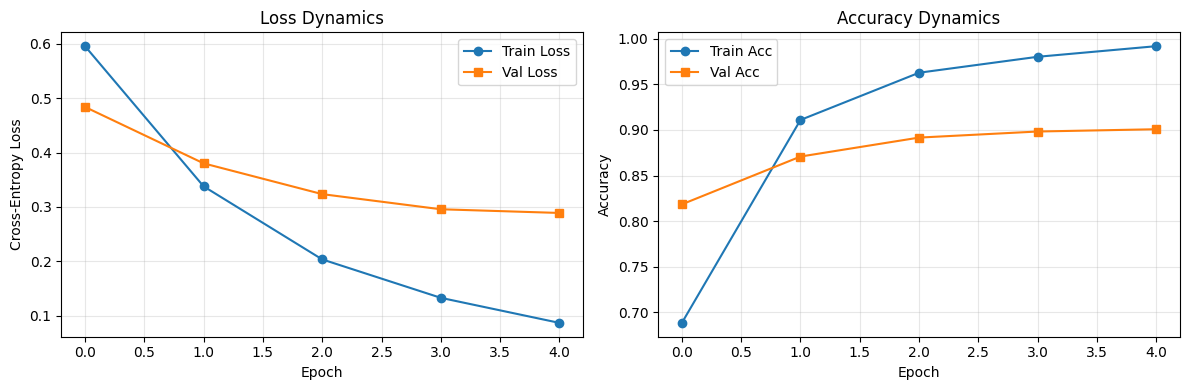

In [16]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], marker="o", label="Train Loss")
plt.plot(history["val_loss"], marker="s", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Loss Dynamics")

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], marker="o", label="Train Acc")
plt.plot(history["val_acc"], marker="s", label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Accuracy Dynamics")

plt.tight_layout()
plt.show()